# Introduction

The dataset analyzed here contains generated houses data from around the World.

Next, we create a RandomForest (Classifier) model for predicting the decision to buy.


# Analysis preparation

## Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

## Read and glimpse the data

In [2]:
df = pd.read_csv("/kaggle/input/global-house-purchase-decision-dataset/global_house_purchase_dataset.csv")

In [3]:
df.columns

Index(['property_id', 'country', 'city', 'property_type', 'furnishing_status',
       'property_size_sqft', 'price', 'constructed_year', 'previous_owners',
       'rooms', 'bathrooms', 'garage', 'garden', 'crime_cases_reported',
       'legal_cases_on_property', 'customer_salary', 'loan_amount',
       'loan_tenure_years', 'monthly_expenses', 'down_payment',
       'emi_to_income_ratio', 'satisfaction_score', 'neighbourhood_rating',
       'connectivity_score', 'decision'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   property_id              200000 non-null  int64  
 1   country                  200000 non-null  object 
 2   city                     200000 non-null  object 
 3   property_type            200000 non-null  object 
 4   furnishing_status        200000 non-null  object 
 5   property_size_sqft       200000 non-null  int64  
 6   price                    200000 non-null  int64  
 7   constructed_year         200000 non-null  int64  
 8   previous_owners          200000 non-null  int64  
 9   rooms                    200000 non-null  int64  
 10  bathrooms                200000 non-null  int64  
 11  garage                   200000 non-null  int64  
 12  garden                   200000 non-null  int64  
 13  crime_cases_reported     200000 non-null  int64  
 14  lega

In [5]:
df.describe()

,property_id,property_size_sqft,price,constructed_year,previous_owners,rooms,bathrooms,garage,garden,crime_cases_reported,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
count,200000.000000,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,2.000000e+05,200000.000000,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,3195.633460,1.215365e+06,1991.487770,3.001370,4.513855,2.760030,0.499350,0.500215,1.229065,...,46528.625830,7.597583e+05,19.986375,10559.693105,4.556068e+05,0.195387,5.498650,5.505240,5.495615,0.230340
std,57735.171256,1613.322287,8.236633e+05,18.494064,2.002198,2.295669,1.840959,0.500001,0.500001,1.185336,...,27997.353766,5.489401e+05,7.081080,5427.241879,3.629865e+05,0.219689,2.875361,2.870945,2.870206,0.421052
min,1.000000,400.000000,5.628800e+04,1960.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,2000.000000,2.350400e+04,10.000000,500.000000,8.966000e+03,0.000000,1.000000,1.000000,1.000000,0.000000
25%,50000.750000,1802.000000,5.659895e+05,1975.000000,1.000000,3.000000,1.000000,0.000000,0.000000,0.000000,...,21450.000000,3.372802e+05,15.000000,5770.000000,1.849592e+05,0.070000,3.000000,3.000000,3.000000,0.000000
50%,100000.500000,3190.000000,1.023429e+06,1991.000000,3.000000,5.000000,2.000000,0.000000,1.000000,1.000000,...,41465.000000,6.269325e+05,20.000000,10520.000000,3.561700e+05,0.130000,5.000000,5.000000,5.000000,0.000000
75%,150000.250000,4589.000000,1.725556e+06,2008.000000,5.000000,7.000000,4.000000,1.000000,1.000000,2.000000,...,70805.000000,1.058416e+06,25.000000,15260.000000,6.257352e+05,0.240000,8.000000,8.000000,8.000000,0.000000
max,200000.000000,6000.000000,4.202732e+06,2023.000000,6.000000,8.000000,8.000000,1.000000,1.000000,10.000000,...,100000.000000,3.520150e+06,30.000000,20000.000000,2.492723e+06,3.460000,10.000000,10.000000,10.000000,1.000000


In [6]:
df.head()

,property_id,country,city,property_type,furnishing_status,property_size_sqft,price,constructed_year,previous_owners,rooms,...,customer_salary,loan_amount,loan_tenure_years,monthly_expenses,down_payment,emi_to_income_ratio,satisfaction_score,neighbourhood_rating,connectivity_score,decision
0,1,France,Marseille,Farmhouse,Semi-Furnished,991,412935,1989,6,6,...,10745,193949,15,6545,218986,0.16,1,5,6,0
1,2,South Africa,Cape Town,Apartment,Semi-Furnished,1244,224538,1990,4,8,...,16970,181465,20,8605,43073,0.08,9,1,2,0
2,3,South Africa,Johannesburg,Farmhouse,Semi-Furnished,4152,745104,2019,5,2,...,21914,307953,30,2510,437151,0.09,6,8,1,0
3,4,Germany,Frankfurt,Farmhouse,Semi-Furnished,3714,1110959,2008,1,3,...,17980,674720,15,8805,436239,0.33,2,6,6,0
4,5,South Africa,Johannesburg,Townhouse,Fully-Furnished,531,99041,2007,6,3,...,17676,65833,25,8965,33208,0.03,3,3,4,0


# Data analysis

In [7]:
print("Distinct values:\n==================")
for col in df.columns:
    print(f"{col} - {df[col].nunique()}")

Distinct values:
property_id - 200000
country - 13
city - 40
property_type - 6
furnishing_status - 3
property_size_sqft - 5601
price - 192130
constructed_year - 64
previous_owners - 7
rooms - 8
bathrooms - 8
garage - 2
garden - 2
crime_cases_reported - 11
legal_cases_on_property - 2
customer_salary - 36020
loan_amount - 187684
loan_tenure_years - 5
monthly_expenses - 6655
down_payment - 180244
emi_to_income_ratio - 266
satisfaction_score - 10
neighbourhood_rating - 10
connectivity_score - 10
decision - 2


In [8]:
print("Most frequent value:\n=====================")
for col in df.columns:
    print(f"{col}: {df[col].value_counts().index[0]} ({df[col].value_counts().values[0]})")

Most frequent value:
property_id: 1 (1)
country: France (15628)
city: Singapore (15278)
property_type: Farmhouse (33518)
furnishing_status: Fully-Furnished (66829)
property_size_sqft: 2390 (60)
price: 478048 (4)
constructed_year: 1991 (3239)
previous_owners: 5 (28734)
rooms: 8 (25359)
bathrooms: 1 (67914)
garage: 0 (100130)
garden: 1 (100043)
crime_cases_reported: 1 (69217)
legal_cases_on_property: 0 (150216)
customer_salary: 13160 (27)
loan_amount: 192440 (5)
loan_tenure_years: 10 (40207)
monthly_expenses: 17510 (82)
down_payment: 197782 (5)
emi_to_income_ratio: 0.06 (9626)
satisfaction_score: 1 (20171)
neighbourhood_rating: 3 (20323)
connectivity_score: 3 (20185)
decision: 0 (153932)


In [9]:
print("Least frequent value:\n=====================")
for col in df.columns:
    print(f"{col}: {df[col].value_counts().index[-1]} ({df[col].value_counts().values[-1]})")

Least frequent value:
property_id: 200000 (1)
country: UAE (15141)
city: Chennai (2510)
property_type: Studio (33008)
furnishing_status: Unfurnished (66498)
property_size_sqft: 944 (14)
price: 732698 (1)
constructed_year: 1995 (3032)
previous_owners: 2 (28333)
rooms: 4 (24675)
bathrooms: 8 (3260)
garage: 1 (99870)
garden: 0 (99957)
crime_cases_reported: 10 (2)
legal_cases_on_property: 1 (49784)
customer_salary: 22644 (1)
loan_amount: 548714 (1)
loan_tenure_years: 20 (39701)
monthly_expenses: 1485 (1)
down_payment: 183984 (1)
emi_to_income_ratio: 2.19 (1)
satisfaction_score: 7 (19902)
neighbourhood_rating: 6 (19696)
connectivity_score: 6 (19872)
decision: 1 (46068)


In [10]:
gr = df.groupby(["country"])["city"].apply(lambda x: set(x)).reset_index()
gr.columns = ["country", "cities"]
gr["city #"] = gr["cities"].apply(lambda x: len(x))
gr

,country,cities,city #
0,Australia,"{Sydney, Brisbane, Melbourne}",3
1,Brazil,"{Rio de Janeiro, São Paulo}",2
2,Canada,"{Montreal, Vancouver, Toronto}",3
3,China,"{Shanghai, Beijing, Shenzhen}",3
4,France,"{Paris, Marseille, Lyon}",3
5,Germany,"{Frankfurt, Munich, Berlin}",3
6,India,"{Bangalore, Delhi, Hyderabad, Pune, Mumbai, Ch...",6
7,Japan,"{Osaka, Kyoto, Tokyo}",3
8,Singapore,{Singapore},1
9,South Africa,"{Cape Town, Johannesburg}",2


In [11]:
df.property_type.unique()

array(['Farmhouse', 'Apartment', 'Townhouse', 'Villa', 'Studio',
       'Independent House'], dtype=object)

In [12]:
df.furnishing_status.unique()

array(['Semi-Furnished', 'Fully-Furnished', 'Unfurnished'], dtype=object)

In [13]:
df.bathrooms.unique()

array([2, 8, 1, 3, 6, 4, 5, 7])

In [14]:
df.rooms.unique()

array([6, 8, 2, 3, 5, 7, 4, 1])

In [15]:
min(df.constructed_year), max(df.constructed_year)

(1960, 2023)

In [16]:
min(df.property_size_sqft), max(df.property_size_sqft)

(400, 6000)

In [17]:
min(df.price), max(df.price)

(56288, 4202732)

# Data visualization

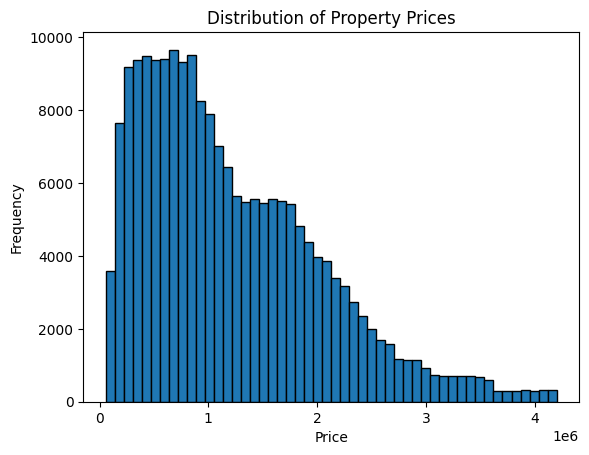

In [18]:
plt.hist(df["price"], bins=50, edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Property Prices")
plt.show()

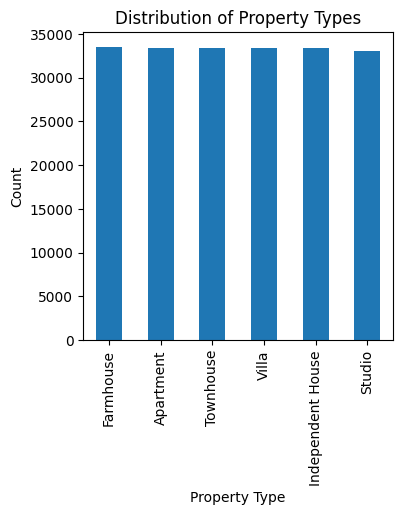

In [19]:
df["property_type"].value_counts().plot(kind="bar", figsize=(4,4))
plt.xlabel("Property Type")
plt.ylabel("Count")
plt.title("Distribution of Property Types")
plt.show()

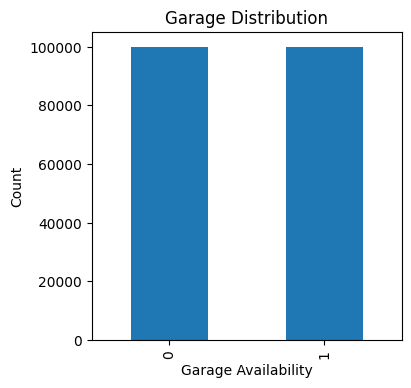

In [20]:
df["garage"].value_counts().plot(kind="bar", figsize=(4,4))
plt.xlabel("Garage Availability")
plt.ylabel("Count")
plt.title("Garage Distribution")
plt.show()

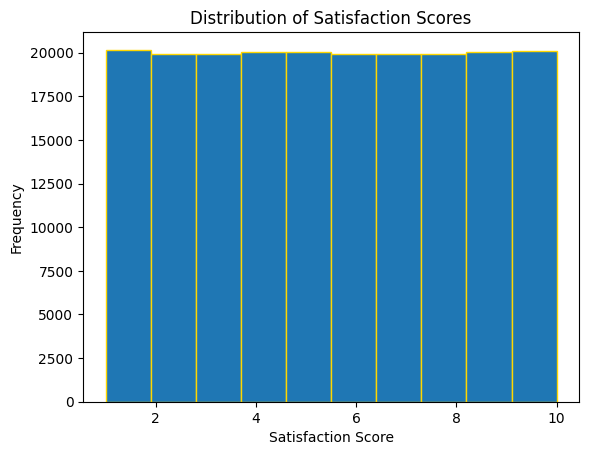

In [21]:
plt.hist(df["satisfaction_score"], bins=10, edgecolor="gold")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")
plt.title("Distribution of Satisfaction Scores")
plt.show()

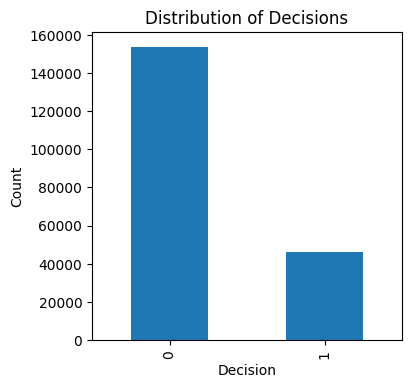

In [22]:
df["decision"].value_counts().plot(kind="bar", figsize=(4, 4))
plt.xlabel("Decision")
plt.ylabel("Count")
plt.title("Distribution of Decisions")
plt.show()

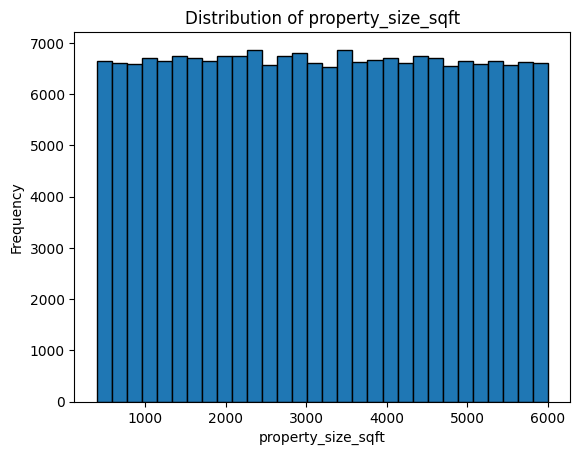

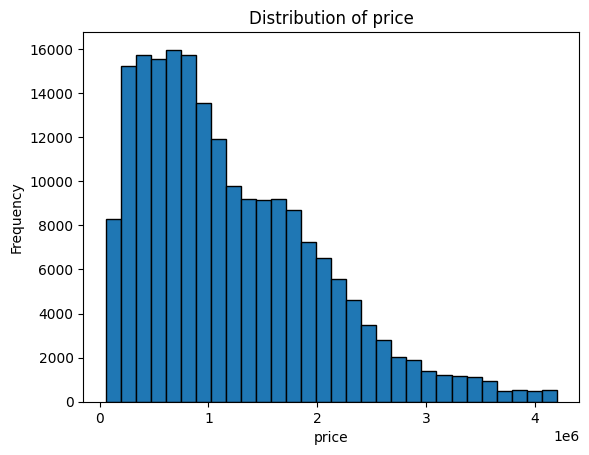

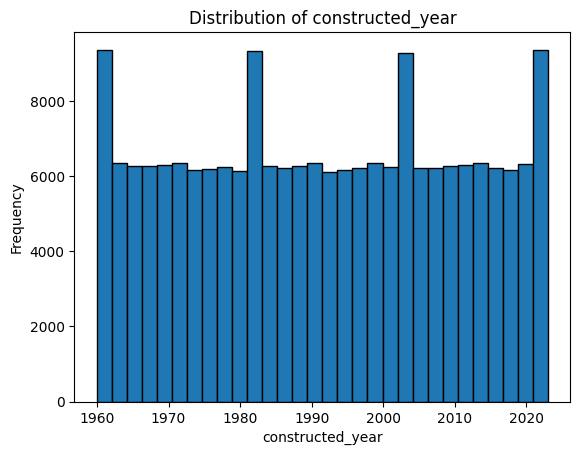

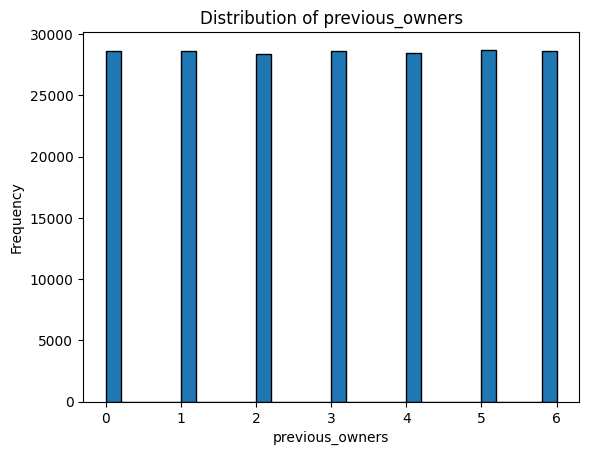

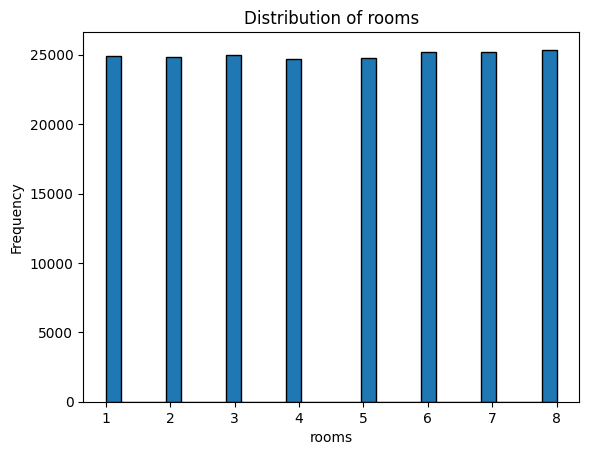

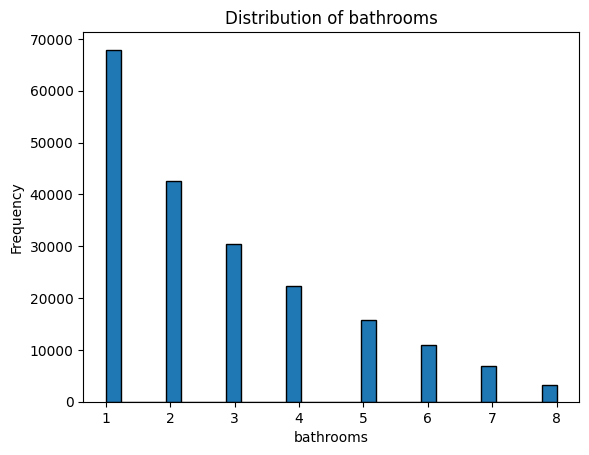

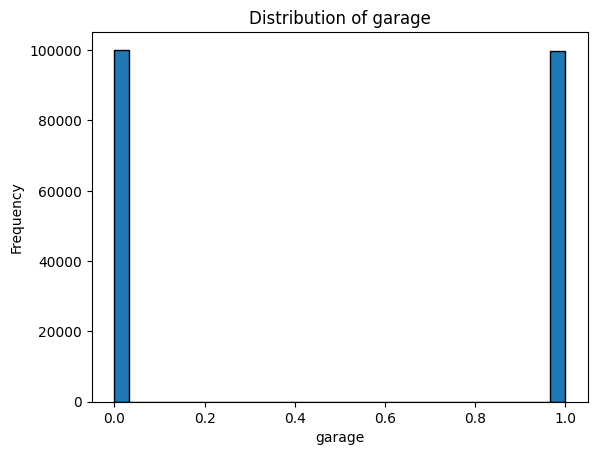

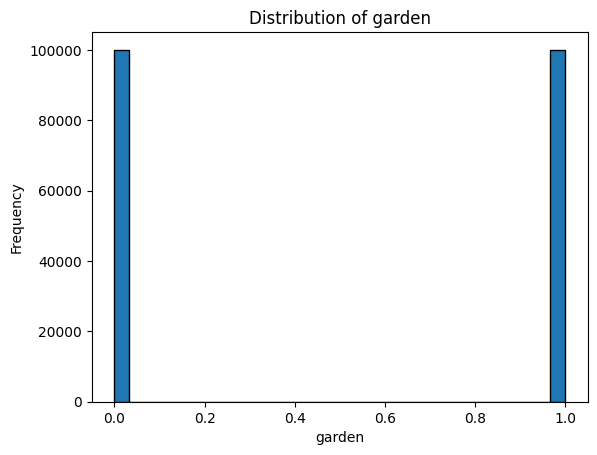

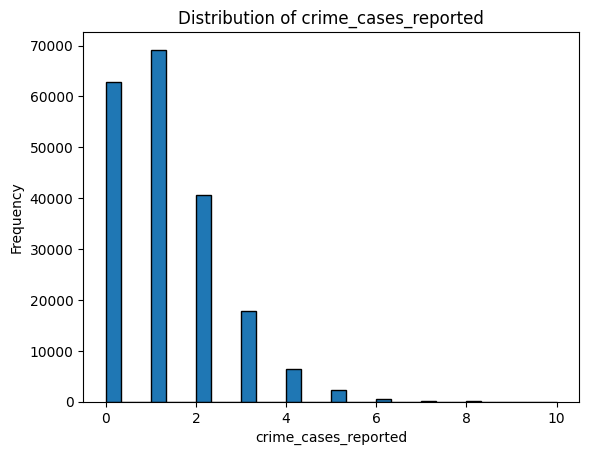

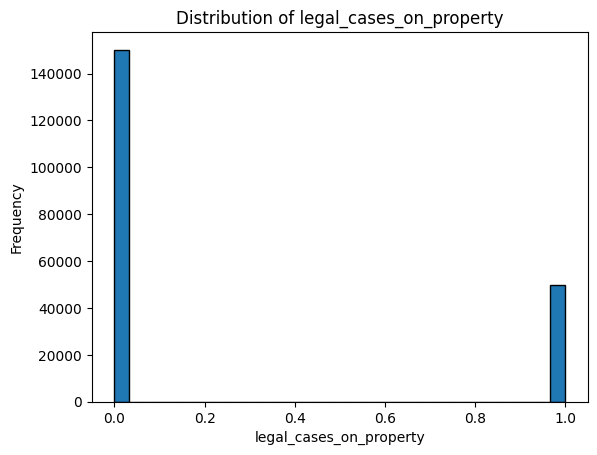

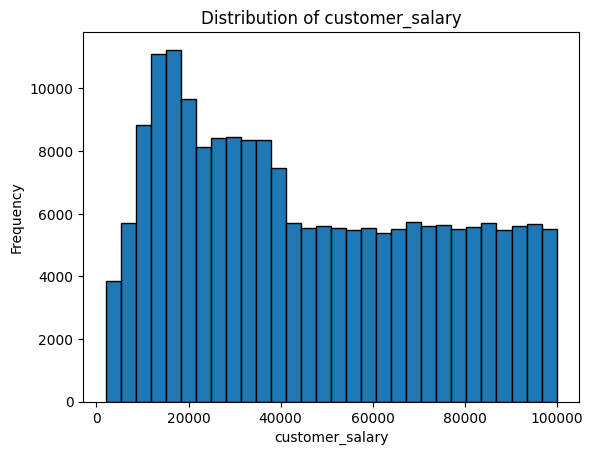

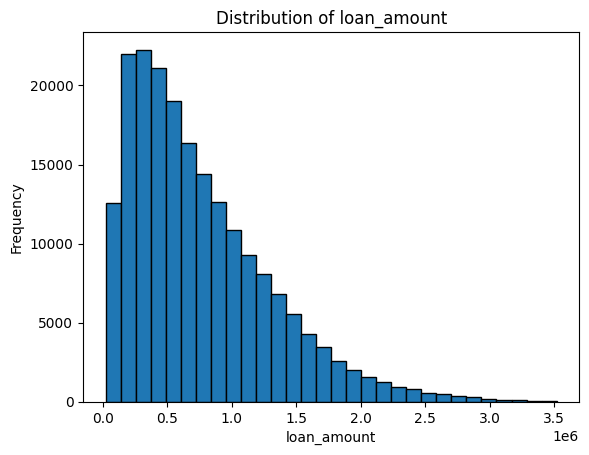

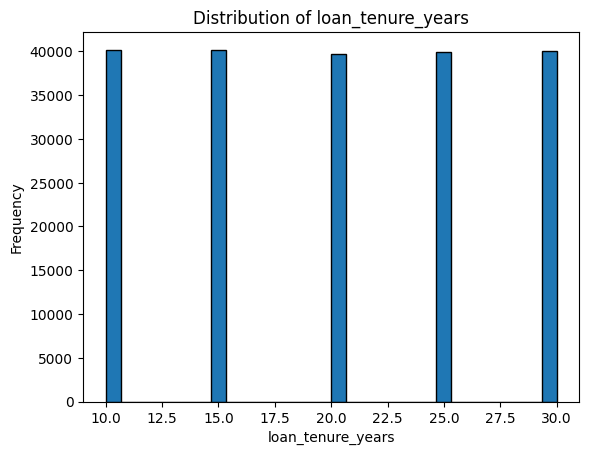

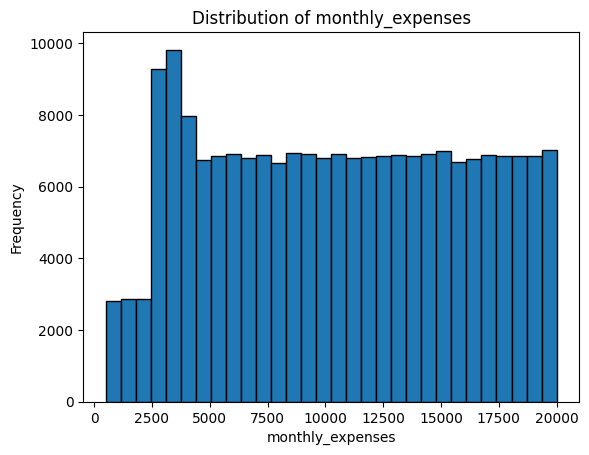

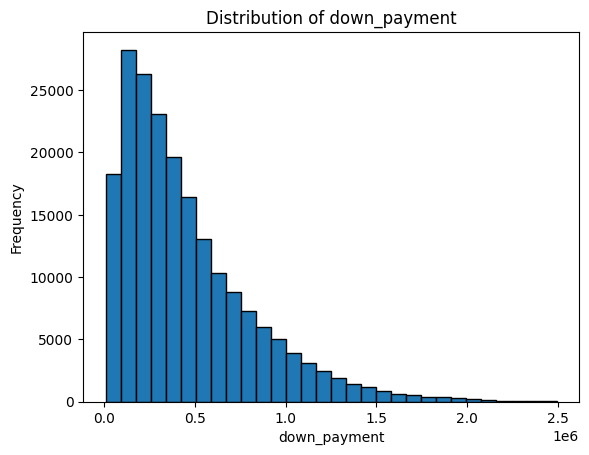

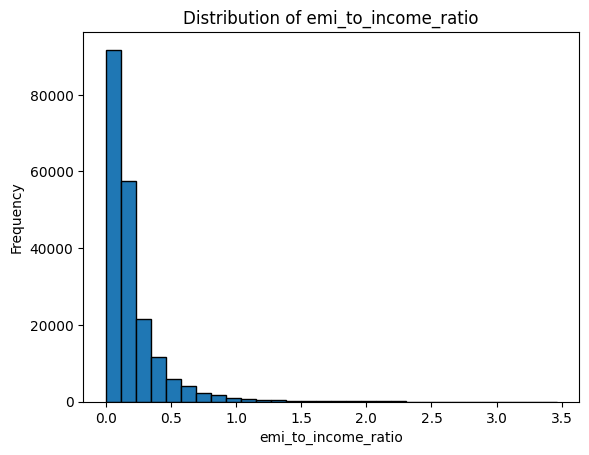

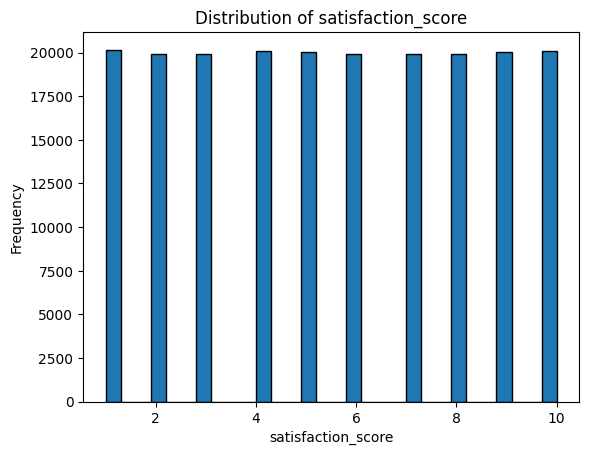

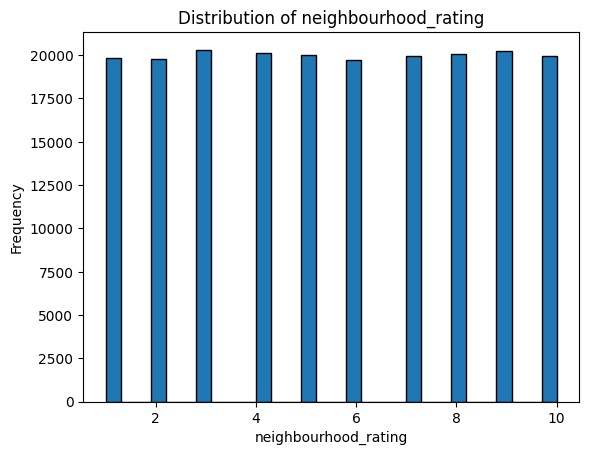

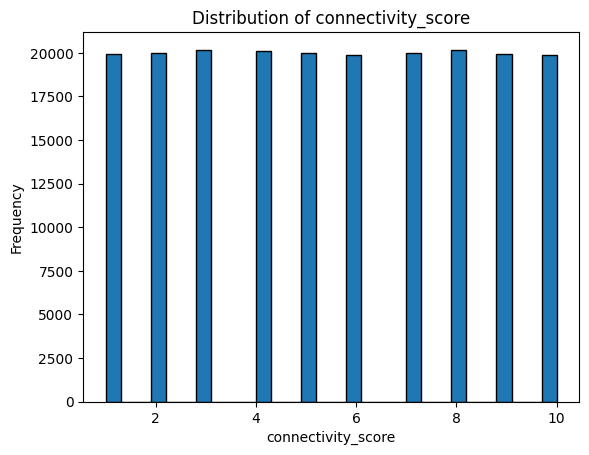

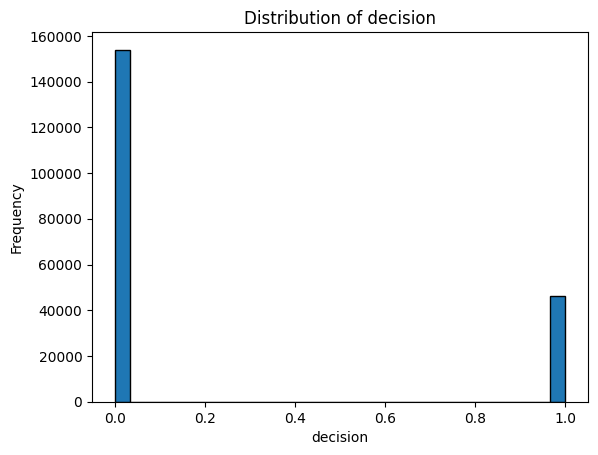

In [23]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    if col == 'property_id':
        continue
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Feature engineering

Drop identifiers.

In [24]:
df = df.drop(columns=["property_id"])

Separate features and target

In [25]:
X = df.drop(columns=["decision"])
y = df["decision"]

Identify categorical and numerical columns

In [26]:
categorical_cols = ["country", "city", "property_type", "furnishing_status"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

Preprocessor: one-hot encode categoricals

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# Model training

Build the model pipeline

In [28]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

Split data using train/test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Fit the model

In [30]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country', 'city',
                                                   'property_type',
                                                   'furnishing_status']),
                                                 ('num', 'passthrough',
                                                  ['property_size_sqft',
                                                   'price', 'constructed_year',
                                                   'previous_owners', 'rooms',
                                                   'bathrooms', 'garage',
                                                   'garden',
                                                   'crime_cases_reported',
                                                   'legal_cases_on_property',
                                                   'customer_salary',
                                                   'loan_amount',
                                                   'loan_tenure_years',
                                                   'monthly_expenses',
                                                   'down_payment',
                                                   'emi_to_income_ratio',
                                                   'satisfaction_score',
                                                   'neighbourhood_rating',
                                                   'connectivity_score'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=20, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

# Evaluate the model

In [31]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [32]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30786
           1       1.00      1.00      1.00      9214

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

ROC-AUC: 1.0


Feature importance.

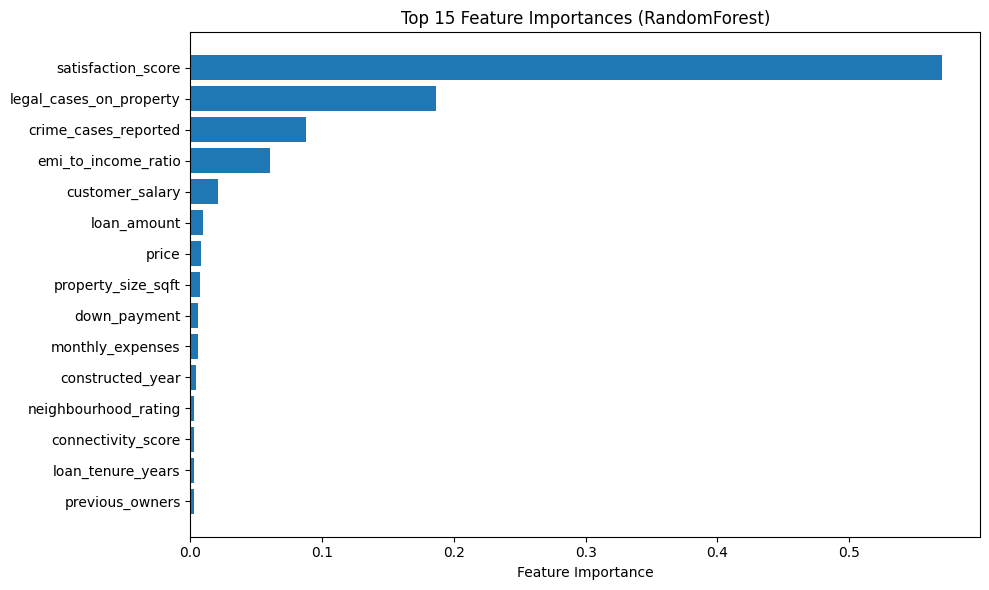

In [33]:
# Get feature names after encoding
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
encoded_cols = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([encoded_cols, numeric_cols])

# Feature importances
rf = model.named_steps["classifier"]
importances = rf.feature_importances_

# Sort importances
indices = np.argsort(importances)[::-1]
top_n = 15

plt.figure(figsize=(10,6))
plt.barh(range(top_n), importances[indices[:top_n]][::-1], align="center")
plt.yticks(range(top_n), [all_feature_names[i] for i in indices[:top_n]][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances (RandomForest)")
plt.tight_layout()
plt.show()